In [30]:
from dataclasses import dataclass
from pathlib import Path
from typing import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from icecream import ic
from jax import random
from jax.scipy.stats import norm, gamma
from jaxtyping import Float, Array
from tqdm import tqdm
from quadax import quadgk

from HPD_estimation_as_multiscale_Z_estimator import HPD_estimator_with_confidence, compute_bandwidth, KDE, TransformedKDE

In [2]:
# Get fake data files
fake_data_folder = Path("../fake_data")
files = [f for f in fake_data_folder.iterdir() if f.is_file() and (f.name != ".DS_Store")]
print(files)

[PosixPath('../fake_data/Gammamoderate_IID_eff=1_M=10000.csv'), PosixPath('../fake_data/LNmoderate_LNAR_eff=0.99999999_M=10000.csv'), PosixPath('../fake_data/Gammaasymmetric_IID_eff=1_M=10000.csv'), PosixPath('../fake_data/LNasymmetric_LNAR_eff=0.99999999_M=10000.csv'), PosixPath('../fake_data/LNsymmetric_LNAR_eff=0.99999999_M=10000.csv'), PosixPath('../fake_data/Gammasymmetric_IID_eff=1_M=10000.csv'), PosixPath('../fake_data/LNasymmetric_LNAR_eff=0.05_M=10000.csv'), PosixPath('../fake_data/LNmoderate_LNAR_eff=0.05_M=10000.csv'), PosixPath('../fake_data/LNsymmetric_LNAR_eff=0.05_M=10000.csv')]


In [4]:
@dataclass
class fakeMCMCdata:
    file_name: str
    target: str
    data_generating_process: str
    efficiency: float
    n_replicates: int
    n_samples: int
    data: jnp.array

def extract_fakeMCMC_data(file: Path):
    target, data_generating_process, efficiency, n_samples = file.name.split("_")
    efficiency = float(efficiency.removeprefix("eff="))
    n_samples = int(n_samples.removeprefix("M=").removesuffix(".csv"))
    data = pl.scan_csv(file).collect().to_numpy()
    return fakeMCMCdata(
        file_name=file.name,
        target=target,
        data_generating_process=data_generating_process,
        efficiency=efficiency,
        n_replicates=data.shape[0],
        n_samples=n_samples,
        data=data
    )

# Create structured objects
data_list = [extract_fakeMCMC_data(file) for file in files]

In [5]:
HPD_LEVEL = 0.95
CI_LEVEL = 0.95
KERNEL = lambda x: 1/jnp.sqrt(2*jnp.pi)*jnp.exp(-x**2/2)
PHI = lambda x: jnp.log(x)
KERNEL_SQUARED_NORM = 1 / (2*jnp.sqrt(jnp.pi))


def estimate_hpd_accross_replicates(fake_mcmc_data: fakeMCMCdata, key: random.PRNGKey):
    if jnp.allclose(fake_mcmc_data.efficiency, 1, rtol=1E-5):
        sample_size = 1_000
    else:
        sample_size = fake_mcmc_data.n_samples
    rows = []
    for id, replicate in enumerate(tqdm(fake_mcmc_data.data), start=1):
        replicate = replicate[:sample_size]
        key, _ = random.split(key)
        hpd_estimate =  HPD_estimator_with_confidence(
            data=replicate,
            alpha=HPD_LEVEL,
            beta=CI_LEVEL,
            kernel=KERNEL,
            phi=PHI,
            kernel_squared_norm=KERNEL_SQUARED_NORM,
            key=key,
            maxiter=10_000,
        )
        results = {
            "method": "multiscale_z_estimator",
            "target": fake_mcmc_data.target,
            "replicate": id,
            "samples_used": len(replicate),
            "data_generating_process": fake_mcmc_data.data_generating_process,
            "efficiency": fake_mcmc_data.efficiency,
            "min": jnp.min(replicate),
            "max": jnp.max(replicate),
            "hpd_target_coverage": HPD_LEVEL,
            "ci_target_coverage": CI_LEVEL,
        }
        rows.append({
            **results,
            "quantity": "HPD_L",
            "point": hpd_estimate.a_hat,
            "lwr": hpd_estimate.a_L,
            "upr": hpd_estimate.a_U,
            "ci_width": hpd_estimate.a_U - hpd_estimate.a_L,
        })
        rows.append({
            **results,
            "quantity": "HPD_U",
            "point": hpd_estimate.b_hat,
            "lwr": hpd_estimate.b_L,
            "upr": hpd_estimate.b_U,
            "ci_width": hpd_estimate.b_U - hpd_estimate.b_L,
        })
    return pl.DataFrame(rows)

In [6]:
results_folder = Path("../fake_data_results")
results_folder.mkdir(exist_ok=True)

# key = random.key(100)
# for fake_mcmc_data in data_list: # asymmetrical gamma is in position 2
#     key, _ = random.split(key)
#     results = estimate_hpd_accross_replicates(fake_mcmc_data, key)
#     file_name = fake_mcmc_data.file_name.removesuffix(".csv") + "_Zestimator.csv"
#     results.write_csv(results_folder / file_name)

In [26]:
files = [f for f in results_folder.iterdir() if f.is_file() and (f.name != ".DS_Store")]
results = [pl.scan_csv(f) for f in files]
for i, file in enumerate(files):
    print(i, file)
# print(results)

0 ../fake_data_results/Gammaasymmetric_IID_eff=1_M=10000_Zestimator.csv
1 ../fake_data_results/LNmoderate_LNAR_eff=0.99999999_M=10000_Zestimator.csv
2 ../fake_data_results/LNsymmetric_LNAR_eff=0.99999999_M=10000_Zestimator.csv
3 ../fake_data_results/Gammamoderate_IID_eff=1_M=10000_Zestimator.csv
4 ../fake_data_results/LNmoderate_LNAR_eff=0.05_M=10000_Zestimator.csv
5 ../fake_data_results/LNasymmetric_LNAR_eff=0.99999999_M=10000_Zestimator.csv
6 ../fake_data_results/LNsymmetric_LNAR_eff=0.05_M=10000_Zestimator.csv
7 ../fake_data_results/Gammasymmetric_IID_eff=1_M=10000_Zestimator.csv
8 ../fake_data_results/LNasymmetric_LNAR_eff=0.05_M=10000_Zestimator.csv


In [19]:
asym_gamma_results = results[0].collect()
asym_gamma_results.head()
a_true = 9.530707E-8
b_true = 4.720740
asym_gamma_results = asym_gamma_results.with_columns(
    pl.when(pl.col("quantity") == "HPD_L").then(a_true).otherwise(b_true).alias("true_value")
)
asym_gamma_results.group_by("quantity").agg(
    ((pl.col("lwr") < pl.col("true_value")) & (pl.col("true_value") < pl.col("upr"))).mean().alias("coverage")
)

quantity,coverage
str,f64
"""HPD_L""",0.396
"""HPD_U""",0.95


In [29]:
asym_lognormal_results = results[5].collect()
asym_lognormal_results.head()
a_true = 0.0260915
b_true = 5.1869484
asym_lognormal_results = asym_lognormal_results.with_columns(
    pl.when(pl.col("quantity") == "HPD_L").then(a_true).otherwise(b_true).alias("true_value")
)
asym_lognormal_results.group_by("quantity").agg(
    ((pl.col("lwr") < pl.col("true_value")) & (pl.col("true_value") < pl.col("upr"))).mean().alias("coverage")
)

quantity,coverage
str,f64
"""HPD_L""",0.818
"""HPD_U""",0.988


In [33]:
asym_lognormal_results.group_by("quantity").agg(
    (pl.col("upr") - pl.col("lwr")).mean().alias("Average interval length")
)

quantity,Average interval length
str,f64
"""HPD_L""",0.028291
"""HPD_U""",1.652188


In [37]:
(asym_lognormal_results.filter(pl.col("quantity") == "HPD_L")["lwr"] < 0).mean()

0.002

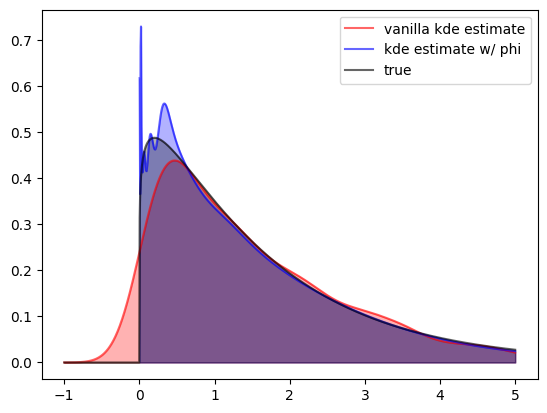

In [32]:
GAMMA_ALPHA = 1.137527
GAMMA_BETA = 0.6899344
key, _ = random.split(random.key(42))
# data = random.gamma(key=key, a=GAMMA_ALPHA, shape=1000) / GAMMA_BETA
data = data_list[2].data[393][:1000]
# asymmetric_gamma_data = data_list[2].data[393]#[:1000]

kde = KDE(data, compute_bandwidth(data), KERNEL)

def create_smoothed_cdf(data, bandwidth):
    # Assumes kernel is gaussian
    return lambda x: jnp.mean(jax.vmap(norm.cdf)((x - data) / bandwidth))
smoothed_cdf = create_smoothed_cdf(data, compute_bandwidth(data))
# phi = lambda x: norm.ppf(smoothed_cdf(x))
phi = lambda x: jnp.log(x)

bandwidth = compute_bandwidth(jax.vmap(phi)(data))
phi_kde = KDE(jax.vmap(phi)(data), bandwidth, KERNEL)
density_estimate_with_phi = TransformedKDE(phi_kde, phi)


plot_data = jnp.linspace(-1, 5, 1000)

plt.plot(plot_data, jax.vmap(kde)(plot_data), c="r", alpha=0.6, label="vanilla kde estimate")
plt.fill_between(plot_data, 0, jax.vmap(kde)(plot_data), color="red", alpha=0.3)

plt.plot(plot_data, jax.vmap(density_estimate_with_phi)(plot_data), c="b", alpha=0.6, label="kde estimate w/ phi")
plt.fill_between(plot_data, 0, jax.vmap(density_estimate_with_phi)(plot_data), color="blue", alpha=0.3)

gamma_density = lambda x: (jnp.pow(GAMMA_BETA, GAMMA_ALPHA) / jax.scipy.special.gamma(GAMMA_ALPHA) * jnp.pow(x, GAMMA_ALPHA - 1) * jnp.exp(- GAMMA_BETA * x)) * (x > 0)
plt.plot(plot_data, jax.vmap(gamma_density)(plot_data), c="k", alpha=0.6, label="true")
plt.fill_between(plot_data, 0, jax.vmap(gamma_density)(plot_data), color="black", alpha=0.3)

plt.legend()




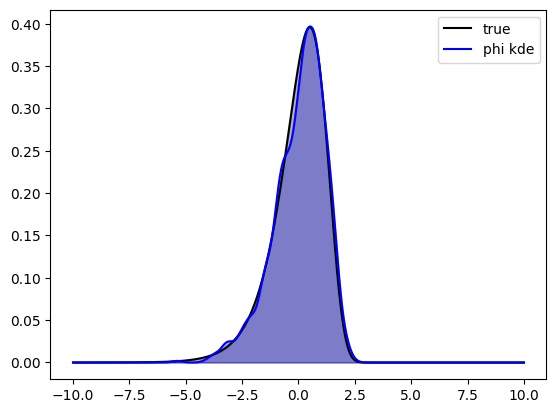

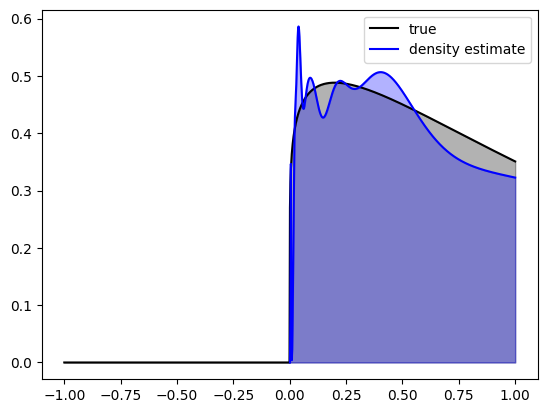

In [22]:
phi = jnp.log
inv_phi = jnp.exp
GAMMA_ALPHA = 1.137527
GAMMA_BETA = 0.6899344
# GAMMA_ALPHA = 1.01
# GAMMA_BETA = 0.6
key, _ = random.split(random.key(3))
data = random.gamma(key=key, a=GAMMA_ALPHA, shape=1000) / GAMMA_BETA
bandwidth = compute_bandwidth(jax.vmap(phi)(data))
phi_kde = KDE(jax.vmap(phi)(data), bandwidth, KERNEL)

# phi = lambda x: norm.ppf(gamma.cdf(x, a=GAMMA_ALPHA, scale=1/GAMMA_BETA))
# inv_phi = lambda x: norm.cdf(gamma.)
plot_x = jnp.linspace(-10, 10, 1000)
phigamma_density = lambda x: gamma_density(inv_phi(x)) / jax.grad(phi)(inv_phi(x))
plt.close()
plt.plot(plot_x, jax.vmap(phigamma_density)(plot_x), color="black", label="true")
plt.fill_between(plot_x, 0, jax.vmap(phigamma_density)(plot_x), color="black", alpha=0.3)

plt.plot(plot_x, jax.vmap(phi_kde)(plot_x), color="blue", label="phi kde")
plt.fill_between(plot_x, 0, jax.vmap(phi_kde)(plot_x), color="blue", alpha=0.3)
plt.legend()
plt.show()
plt.close()


plot_x = jnp.linspace(-1, 1, 1000)
plt.plot(plot_x, jax.vmap(gamma_density)(plot_x), color="black", label="true")
plt.fill_between(plot_x, 0, jax.vmap(gamma_density)(plot_x), color="black", alpha=0.3)

plt.plot(plot_x, jax.vmap(lambda x: phi_kde(phi(x))*jax.grad(phi)(x))(plot_x), color="blue", label="density estimate")
plt.fill_between(plot_x, 0, jax.vmap(lambda x: phi_kde(phi(x))*jax.grad(phi)(x))(plot_x), color="blue", alpha=0.3)
plt.legend()
plt.show()
plt.close()